In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(progressr)
  library(furrr)
  library(caret)
  library(doParallel)
  library(plotROC)
})

complement <- function(x) {
  return(chartr("acgtnACGTN", "tgcanTGCAN", x))
}
reverseComplement <- function(x) {
  if(is.character(x))
    return(stringi::stri_reverse(complement(x)))
  else if (length(x) > 1)
    return(lapply(x, reverseComplement))
}

params <- list(threads=6,
               test_chr="chr12")
# set up defaults for BASH scripts
Sys.setenv(THREADS=params$threads)
Sys.setenv(TEST_CHR=params$test_chr)

# Random forest classification of rastair called positions

We will ultimately have to do this in Rust, but we can use R here to generate the input matrices more easily, and to test the performance.

## 0. Load data

In [3]:
raw_data <- fread(cmd=paste0("bcftools query -f '%CHROM\\t%POS\\t%REF\\t%ALT\\t%AD\\t%MQ\\t%MQ0\\t%AS_SB\\t%SC5\\t%ABQ\\t%AS_SS_BQ\\t%AMQ\\t%AS_SS_MQ\\t%PIR\\t%ENT100\\t%NAB\\t%NOI\\t%CPG[\\t%DP\\t%M5mC]\\n' Analysis/data/test_", params$test_chr,".bcf"), header=FALSE, stringsAsFactors = FALSE, na.strings = c("", ".", "<*>"))
setnames(raw_data, c("chr", "pos", "ref", "alt", "allele_depth", "mapq", "num_mapq0", "strand_bias", "sequence_context", "base_qual", "as_ss_bq", "map_qual", "as_ss_mq", "pos_in_read", "region_entropy", "num_aligned_bases", "num_indels", "is_cpg", "depth", "beta"))

Next, we have to split the multi-allelics into separate rows, and also split the per-allele data accordingly

In [4]:
split_multiallelics <- function(dt) {
  alleles <- strsplit(dt$alt, ",")[[1]]
  allele_depths <- strsplit(dt$allele_depth, ",")[[1]]
  strand_bias <- strsplit(dt$strand_bias, ",")[[1]]
  base_quals <- strsplit(dt$base_qual, ",")[[1]]
  map_quals <- strsplit(dt$map_qual, ",")[[1]]
  as_baseq <- strsplit(dt$as_ss_bq, ",")[[1]]
  as_mapq <- strsplit(dt$as_ss_mq, ",")[[1]]
  pos_in_read <- strsplit(dt$pos_in_read, ",")[[1]]
  num_aligned_bases <- strsplit(dt$num_aligned_bases, ",")[[1]]
  num_indels <- strsplit(dt$num_indels, ",")[[1]]

  # compose new table for returning
  output <- list(ref=rep(dt$ref, length(alleles)),
                 alt=alleles,
                 mapq=dt$mapq,
                 num_mapq0=dt$num_mapq0,
                 sequence_context=dt$sequence_context,
                 is_cpg=dt$is_cpg,
                 depth=dt$depth,
                 beta=dt$beta,
                 region_entropy=dt$region_entropy)
  for (i in 1:length(alleles)) {
    output$ad_ref <- append(output$ad_ref, as.numeric(allele_depths[1]))
    output$ad_alt <- append(output$ad_alt, as.numeric(allele_depths[i+1]))

    output$sb_ot_ref <- append(output$sb_ot_ref, as.numeric(strand_bias[1]))
    output$sb_ob_ref <- append(output$sb_ob_ref, as.numeric(strand_bias[2]))
    output$sb_ot_alt <- append(output$sb_ot_alt, as.numeric(strand_bias[i*2+1]))
    output$sb_ob_alt <- append(output$sb_ob_alt, as.numeric(strand_bias[i*2+2]))

    output$bq_ref <- append(output$bq_ref, as.numeric(base_quals[1]))
    output$bq_alt <- append(output$bq_alt, as.numeric(base_quals[i+1]))

    output$bq_ot_ref <- append(output$bq_ot_ref, as.numeric(as_baseq[1]))
    output$bq_ob_ref <- append(output$bq_ob_ref, as.numeric(as_baseq[2]))

    output$bq_ot_alt <- append(output$bq_ot_alt, as.numeric(as_baseq[i*2+1]))
    output$bq_ob_alt <- append(output$bq_ob_alt, as.numeric(as_baseq[i*2+2]))

    output$mq_ref <- append(output$mq_ref, as.numeric(map_quals[1]))
    output$mq_alt <- append(output$mq_alt, as.numeric(map_quals[i+1]))

    output$mq_ot_ref <- append(output$mq_ot_ref, as.numeric(as_mapq[1]))
    output$mq_ob_ref <- append(output$mq_ob_ref, as.numeric(as_mapq[2]))

    output$mq_ot_alt <- append(output$mq_ot_alt, as.numeric(as_mapq[i*2+1]))
    output$mq_ob_alt <- append(output$mq_ob_alt, as.numeric(as_mapq[i*2+2]))

    output$pos_in_read_ref <- append(output$pos_in_read_ref, as.numeric(pos_in_read[1]))
    output$pos_in_read_alt <- append(output$pos_in_read_alt, as.numeric(pos_in_read[i+1]))


    output$num_aligned_bases_ref <- append(output$num_aligned_bases_ref, as.numeric(num_aligned_bases[1]))
    output$num_aligned_bases_alt <- append(output$num_aligned_bases_alt, as.numeric(num_aligned_bases[i+1]))

    output$num_indels_ref <- append(output$num_indels_ref, as.numeric(num_indels[1]))
    output$num_indels_alt <- append(output$num_indels_alt, as.numeric(num_indels[i+1]))
  }
  return(output)
}

# temporarily annotate with group id from 1:100
raw_data[, g := cut(raw_data$pos, 100)]

In [5]:
plan(multisession, workers = params$threads)
raw_data <- rbindlist(future_map(split(raw_data, by="g"), function(subtable){
        x <- subtable[, split_multiallelics(.SD), by=.(chr, pos)]
        return(x)
      }
    )
)
# Close threads
plan(sequential)
raw_data[, chr := as.factor(chr)]
raw_data[, ref := as.factor(ref)]
raw_data[, alt := as.factor(alt)]
raw_data[, sequence_context := as.factor(sequence_context)]

Next, we need to load the truth set and subset it to the covered positions

In [7]:
truth.set <- fread(cmd=paste0("bcftools query -r ", params$test_chr, " -f '%CHROM\\t%POS\\t%REF\\t%ALT[\\t%GT]\\n' -i 'TYPE=\"SNP\" & FILTER=\"PASS\"' Analysis/data/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"), header=FALSE, stringsAsFactors = TRUE)
setnames(truth.set, c("chr", "pos", "ref", "alt", "genotype"))

# subset truth set to regions that could have been called at all - not fair to compare regions without coverage
setkey(truth.set, chr, pos, ref, alt)
setkey(raw_data, chr, pos, ref, alt)
truth.set <- truth.set[raw_data[, .(chr, pos, ref, alt)], nomatch=NULL]

Now, we merge the training data onto the raw data:

In [8]:
training_data.long <- truth.set[, .(chr, pos, ref, alt, is.snp=TRUE)][raw_data[ref!="N"]]
training_data.long[is.na(is.snp), is.snp := FALSE]

# Only keep positions where there is _any_ evidence of alt
training_data.long <-training_data.long[ad_alt > 0 & !is.na(ad_alt) & !alt=="N"]

# Save memory
rm(raw_data)

## 1. Train a model for CpGs

First, we create a subset of the data for CpG positions and turn this into a data frame for training, ie one-hot encode all bases and normalise to depth:

In [15]:
training_data.cpg <- training_data.long[
    ref=="C"&substr(sequence_context, 4,4)=="G" | ref=="G"&substr(sequence_context, 2,2)=="C",
    .(location=paste0(chr, ":", pos, "_", ref, ">" ,alt),
      chr,
      pos,
      ref,
      alt,
      is.snp,
      mapq,
      num_mapq0,
      p1 = substr(sequence_context, 1, 1),
      p2 = substr(sequence_context, 2, 2),
      p4 = substr(sequence_context, 4, 4),
      p5 = substr(sequence_context, 5, 5),
      region_entropy,
      ad_ref=ad_ref/depth,
      ad_alt=ad_alt/depth,
      sb_ot_ref = sb_ot_ref/depth,
      sb_ob_ref = sb_ob_ref/depth,
      sb_ot_alt = sb_ot_alt/depth,
      sb_ob_alt = sb_ob_alt/depth,
      alt_score = fifelse(ref=="C", log2(sb_ob_alt*bq_ob_alt+1)-log2(sb_ob_ref*bq_ob_ref+1), log2(sb_ot_alt*bq_ot_alt+1)-log2(sb_ot_ref*bq_ot_ref+1)),
      beta = fifelse(ref=="C", sb_ot_alt/(sb_ot_alt+sb_ot_ref), sb_ob_alt/(sb_ob_alt+sb_ob_ref)),
      bq_ref,
      bq_alt,
      bq_ot_ref,
      bq_ob_ref,
      bq_ot_alt,
      bq_ob_alt,
      mq_ot_ref,
      mq_ob_ref,
      mq_ot_alt,
      mq_ob_alt,
      mq_ref,
      mq_alt,
      pos_in_read_ref,
      pos_in_read_alt,
      num_aligned_bases_ref,
      num_aligned_bases_alt,
      num_indels_ref,
      num_indels_alt
      )
  ]

In [16]:
# add info about alt alleles in adjacent position
setkey(training_data.cpg, chr, pos)
training_data.cpg.c <- training_data.cpg[ref=="C"]
training_data.cpg.g <- training_data.cpg[ref=="G"]

setkey(training_data.cpg.c, chr, pos)
setkey(training_data.cpg.g, chr, pos)
training_data.cpg.c <- training_data.cpg.g[alt=="A", .(ad_alt_adj=mean(ad_alt), alt_score_adj = mean(alt_score), beta_adj=mean(beta)), keyby=.(chr, pos=pos-1)][training_data.cpg.c]
training_data.cpg.g <- training_data.cpg.c[alt=="T", .(ad_alt_adj=mean(ad_alt), alt_score_adj = mean(alt_score), beta_adj=mean(beta)), keyby=.(chr, pos=pos+1)][training_data.cpg.g]

training_data.cpg <- rbind(training_data.cpg.c, training_data.cpg.g)
rm(training_data.cpg.c, training_data.cpg.g)
training_data.cpg[, beta_ratio_adj := log2((fifelse(is.na(beta), 0, beta)+1))-log2((fifelse(is.na(beta_adj), 0, beta_adj)+1))]
training_data.cpg[is.na(ad_alt_adj), ad_alt_adj := 0]
training_data.cpg[is.na(alt_score_adj), alt_score_adj := 0]

training_data.cpg[, chr:=NULL]
training_data.cpg[, pos:=NULL]
training_data.cpg[, beta := NULL]
training_data.cpg[, beta_adj := NULL]

# turn into a data frame and remove location names
setDF(training_data.cpg)
rownames(training_data.cpg) <- training_data.cpg[,"location"]
training_data.cpg <- training_data.cpg[, colnames(training_data.cpg)!="location"]

# one-hot encode all categorical variables
training_data.cpg.dm <- dummyVars(" is.snp ~ .", data = training_data.cpg)
training_data.cpg.dm <- data.frame(predict(training_data.cpg.dm, newdata = training_data.cpg))
training_data.cpg.dm <- cbind(training_data.cpg.dm, data.frame(is.snp=as.factor(fifelse(training_data.cpg$is.snp, "SNP","REF"))))

rm(training_data.cpg)

# remove one-hot columns that encode an N, I will ignore those to simplify the table
training_data.cpg.dm <- training_data.cpg.dm[, !grepl("N", colnames(training_data.cpg.dm), fixed=TRUE)]

Save the training data as a text file to re-do the training in Rust

In [17]:
fwrite(training_data.cpg.dm, paste0("Analysis/data/", params$test_chr, "_CpG_features.txt.gz"), sep="\t", quote=FALSE, row.names=TRUE, col.names=TRUE, showProgress=FALSE, compress="gzip", scipen=15)

Next, we train the model on a random subset of positions

In [18]:
# Create a smaller training dataset with a pos:neg ratio of 1:3, ie a little more balanced than the actual data
indices.snp <- (1:nrow(training_data.cpg.dm))[training_data.cpg.dm$is.snp=="SNP"]
indices.ref <- (1:nrow(training_data.cpg.dm))[training_data.cpg.dm$is.snp=="REF"]

indices.train <- c(indices.snp[sample.int(length(indices.snp), 4000)], indices.ref[sample.int(length(indices.ref), 16000)])
rm(indices.snp, indices.ref)

# train a random forest
cl <- makePSOCKcluster(params$threads)
registerDoParallel(cl)
tunegrid <- expand.grid(.mtry=c(2,4,7))
ctrl <- trainControl(## 10-fold CV
                    method = "cv",
                    summaryFunction=twoClassSummary,
                    classProbs=TRUE,
                    savePredictions = TRUE,
                    number = 5,
                    ## repeated x times
                    #repeats = 3,
                    allowParallel=TRUE                    )

model.cpg <- train(is.snp ~ ., data=training_data.cpg.dm[indices.train,], method="rf", trControl=ctrl, tuneGrid=tunegrid, ntree=1000)
stopCluster(cl)

Warning message in train.default(x, y, weights = w, ...):
“The metric "Accuracy" was not in the result set. ROC will be used instead.”


In [19]:
print(model.cpg)

Random Forest 

20000 samples
   55 predictor
    2 classes: 'REF', 'SNP' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 16000, 16000, 16000, 16000, 16000 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec   
  2     0.9966077  0.9954375  0.96475
  4     0.9969921  0.9948125  0.97025
  7     0.9969464  0.9950000  0.97025

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 4.


Warning message in verify_d(data$d):
“D not labeled 0/1, assuming REF = 0 and SNP = 1!”


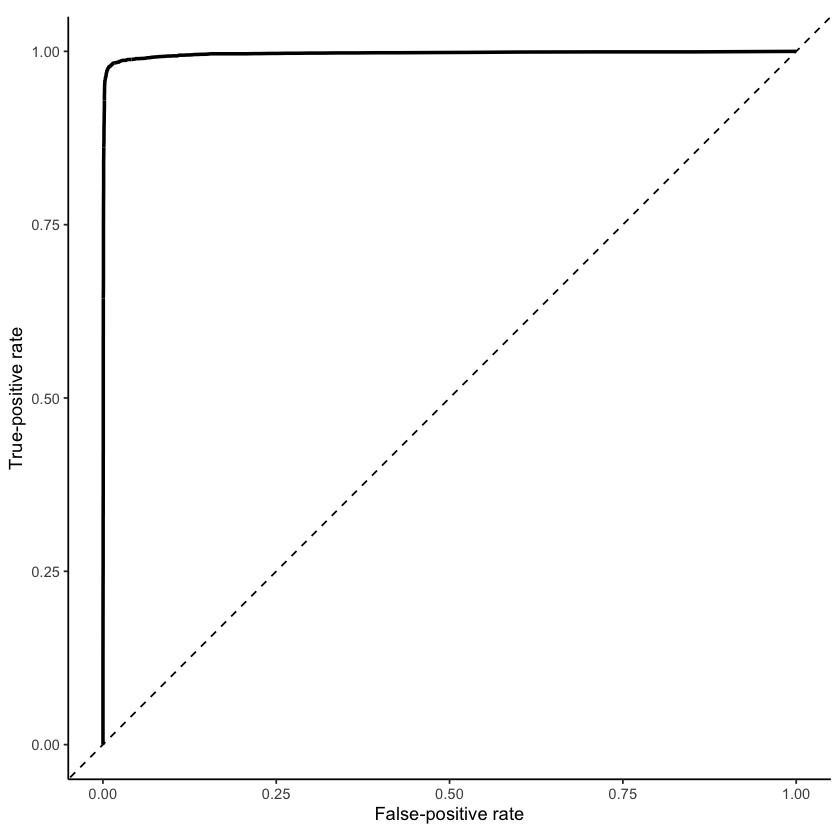

In [20]:
ggplot(model.cpg$pred[model.cpg$pred$mtry==2 ,],
       aes(m = SNP, d = factor(obs, levels = c("SNP", "REF")))) +
    geom_roc(hjust = -0.4, vjust = 1.5, n.cuts = 0) + geom_abline(intercept = 0, lty=2) + coord_equal() + theme_classic() + xlab("False-positive rate") + ylab("True-positive rate")
# best fit seems to be 28 to me, so I will update the model
#model.cpg <- update(model.cpg, param=list(mtry=7))

In [21]:
confusionMatrix(data=model.cpg$pred[model.cpg$pred$mtry==2,]$pred, reference = model.cpg$pred[model.cpg$pred$mtry==2,]$obs, positive = "SNP")

Confusion Matrix and Statistics

          Reference
Prediction   REF   SNP
       REF 15927   141
       SNP    73  3859
                                          
               Accuracy : 0.9893          
                 95% CI : (0.9878, 0.9907)
    No Information Rate : 0.8             
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9663          
                                          
 Mcnemar's Test P-Value : 4.649e-06       
                                          
            Sensitivity : 0.9647          
            Specificity : 0.9954          
         Pos Pred Value : 0.9814          
         Neg Pred Value : 0.9912          
             Prevalence : 0.2000          
         Detection Rate : 0.1930          
   Detection Prevalence : 0.1966          
      Balanced Accuracy : 0.9801          
                                          
       'Positive' Class : SNP             
                  

It would be useful to also investigate which features provide information:

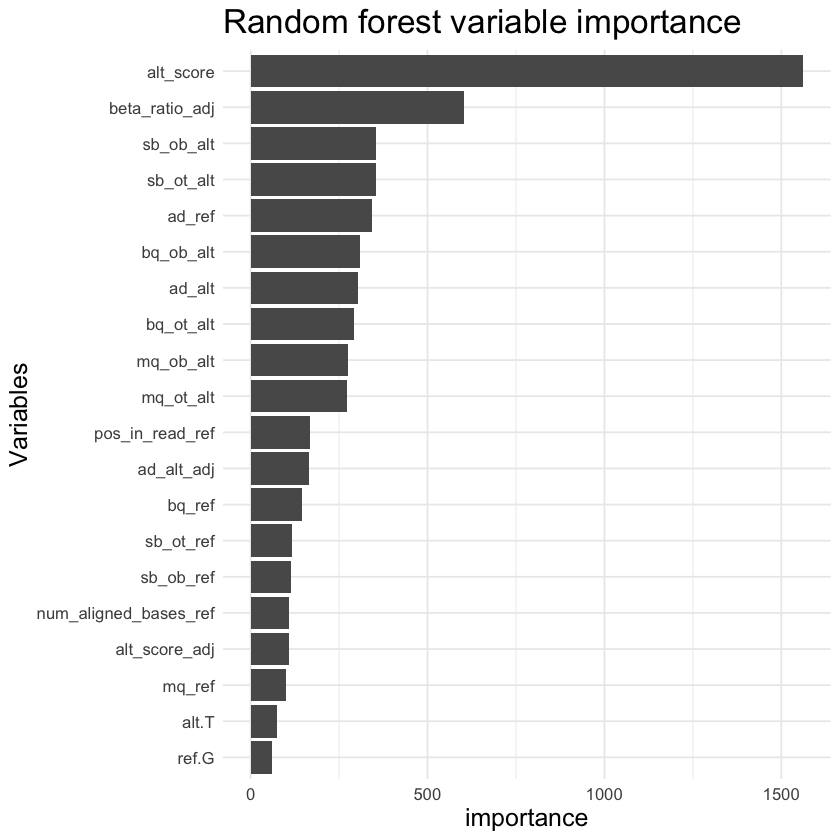

In [22]:
## Get variable importance, and turn into a data frame
var_imp <- varImp(model.cpg, scale=FALSE)$importance
var_imp <- data.table(variables=row.names(var_imp), importance=var_imp$Overall)

## Create a plot of variable importance
ggplot(tail(var_imp[order(importance)], n=20), aes(x=reorder(variables, importance), y=importance)) +
        ## Plot the bar graph
        geom_bar(stat='identity') +
        ## Flip the graph to make a horizontal bar plot
        coord_flip() +
        ## Add x-axis label
        xlab('Variables') +
        ## Add a title
        labs(title='Random forest variable importance') +
        ## Some layout for the plot
        theme_minimal() +
        theme(axis.text = element_text(size = 10),
              axis.title = element_text(size = 15),
              plot.title = element_text(size = 20),
              )

## 2. Train a model for de-novo CpGs

In [36]:
training_data.denovo <- training_data.long[
    alt=="C"&substr(sequence_context, 4,4)=="G" | alt=="G"&substr(sequence_context, 2,2)=="C",
    .(location=paste0(chr, ":", pos, "_", ref, ">" ,alt),
      chr,
      pos,
      ref,
      alt,
      is.snp,
      mapq,
      num_mapq0,
      p1 = substr(sequence_context, 1, 1),
      p2 = substr(sequence_context, 2, 2),
      p4 = substr(sequence_context, 4, 4),
      p5 = substr(sequence_context, 5, 5),
      region_entropy,
      ad_ref=ad_ref/depth,
      ad_alt=ad_alt/depth,
      sb_ot_ref = sb_ot_ref/depth,
      sb_ob_ref = sb_ob_ref/depth,
      sb_ot_alt = sb_ot_alt/depth,
      sb_ob_alt = sb_ob_alt/depth,
      alt_score = fifelse(alt=="C", log2(sb_ob_alt*bq_ob_alt+1)-log2(sb_ob_ref*bq_ob_ref+1), log2(sb_ot_alt*bq_ot_alt+1)-log2(sb_ot_ref*bq_ot_ref+1)),
      bq_ref,
      bq_alt,
      bq_ot_ref,
      bq_ob_ref,
      bq_ot_alt,
      bq_ob_alt,
      mq_ot_ref,
      mq_ob_ref,
      mq_ot_alt,
      mq_ob_alt,
      mq_ref,
      mq_alt,
      pos_in_read_ref,
      pos_in_read_alt,
      num_aligned_bases_ref,
      num_aligned_bases_alt,
      num_indels_ref,
      num_indels_alt
      )
  ]

# add info about alt alleles in adjacent position
setkey(training_data.denovo, chr, pos)
training_data.denovo.c <- training_data.denovo[alt=="C"]
training_data.denovo.g <- training_data.denovo[alt=="G"]

setkey(training_data.denovo.c, chr, pos)
setkey(training_data.denovo.g, chr, pos)

# Annotate with the number of T/A alleles at the same position and use that to calculate beta
training_data.denovo.c[ref=="T", beta := sb_ot_ref/(sb_ot_alt+sb_ot_ref)]
beta.t <- training_data.denovo.c[ref!="T"][training_data.long[alt=="T", .(chr, pos, ad_ot_t=sb_ot_alt)], .(chr, pos, b = ad_ot_t / (ad_ot_t + sb_ot_alt)), nomatch=NULL]
training_data.denovo.c[beta.t, beta := b, on=.(chr, pos)]

training_data.denovo.g[ref=="A", beta := sb_ob_ref/(sb_ob_alt+sb_ob_ref)]
beta.a <- training_data.denovo.g[ref!="A"][training_data.long[alt=="A", .(chr, pos, ad_ob_a=sb_ob_alt)], .(chr, pos, b = ad_ob_a / (ad_ob_a + sb_ob_alt))]
training_data.denovo.g[beta.a, beta := b, on=.(chr, pos)]

rm(beta.t, beta.a)

training_data.denovo.c[is.na(beta), beta := 0]
training_data.denovo.g[is.na(beta), beta := 0]

# Annotate with adjacent value
training_data.denovo.c <- training_data.long[ref=="G" & alt=="A", .(ad_alt_adj=sum(ad_alt)/sum(depth), alt_score_adj = log2(sb_ot_alt*bq_ot_alt+1)-log2(sb_ot_ref*bq_ot_ref+1), beta_adj=sum(sb_ob_alt)/sum(sb_ob_alt+sb_ob_ref), sb_adj=(sb_ob_alt+1)/(sb_ot_alt+1)), keyby=.(chr, pos=pos-1)][training_data.denovo.c]
training_data.denovo.g <- training_data.long[ref=="C" & alt=="T", .(ad_alt_adj=sum(ad_alt)/sum(depth), alt_score_adj = log2(sb_ob_alt*bq_ob_alt+1)-log2(sb_ob_ref*bq_ob_ref+1), beta_adj=sum(sb_ot_alt)/sum(sb_ot_alt+sb_ot_ref), sb_adj=(sb_ot_alt+1)/(sb_ob_alt+1)), keyby=.(chr, pos=pos+1)][training_data.denovo.g]

training_data.denovo <- rbind(training_data.denovo.c, training_data.denovo.g)
rm(training_data.denovo.c, training_data.denovo.g)
training_data.denovo[, beta_ratio_adj := log2(fifelse(is.na(beta), 0, beta)+1)-log2(fifelse(is.na(beta_adj), 0, beta_adj)+1)]
training_data.denovo[is.na(ad_alt_adj), ad_alt_adj := 0]
training_data.denovo[is.na(alt_score_adj), alt_score_adj := 0]
training_data.denovo[is.na(sb_adj), sb_adj := 0]

training_data.denovo[, chr:=NULL]
training_data.denovo[, pos:=NULL]
training_data.denovo[, beta:=NULL]
training_data.denovo[, beta_adj:=NULL]

# turn into a data frame and remove location names
setDF(training_data.denovo)
rownames(training_data.denovo) <- training_data.denovo[,"location"]
training_data.denovo <- training_data.denovo[, colnames(training_data.denovo)!="location"]

# one-hot encode all categorical variables
training_data.denovo.dm <- dummyVars(" is.snp ~ .", data = training_data.denovo)
training_data.denovo.dm <- data.frame(predict(training_data.denovo.dm, newdata = training_data.denovo))
training_data.denovo.dm <- cbind(training_data.denovo.dm, data.frame(is.snp=as.factor(fifelse(training_data.denovo$is.snp, "SNP","REF"))))

rm(training_data.denovo)

training_data.denovo.dm <- training_data.denovo.dm[, !grepl("N", colnames(training_data.denovo.dm), fixed=TRUE)]

Save for later:

In [38]:
fwrite(training_data.denovo.dm, paste0("Analysis/data/", params$test_chr, "_denovo_features.txt.gz"), sep="\t", quote=FALSE, row.names=TRUE, col.names=TRUE, showProgress=FALSE, compress="gzip", scipen=15)

In [39]:
# Create a smaller training dataset with a pos:neg ratio of 1:3, ie a little more balanced than the actual data
indices.snp <- (1:nrow(training_data.denovo.dm))[training_data.denovo.dm$is.snp=="SNP"]
indices.ref <- (1:nrow(training_data.denovo.dm))[training_data.denovo.dm$is.snp=="REF"]

indices.train <- c(indices.snp[sample.int(length(indices.snp), 4000)], indices.ref[sample.int(length(indices.ref), 16000)])
rm(indices.snp, indices.ref)

# train a random forest
cl <- makePSOCKcluster(params$threads)
registerDoParallel(cl)
tunegrid <- expand.grid(.mtry=c(2,4,7))
ctrl <- trainControl(## 10-fold CV
                    method = "cv",
                    summaryFunction=twoClassSummary,
                    classProbs=TRUE,
                    savePredictions = TRUE,
                    number = 5,
                    ## repeated x times
                    #repeats = 3,
                    allowParallel=TRUE                    )

model.denovo <- train(is.snp ~ ., data=training_data.denovo.dm[indices.train,], method="rf", trControl=ctrl, tuneGrid=tunegrid, ntree=1000)
stopCluster(cl)

Warning message in train.default(x, y, weights = w, ...):
“The metric "Accuracy" was not in the result set. ROC will be used instead.”


Random Forest 

20000 samples
   56 predictor
    2 classes: 'REF', 'SNP' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 16000, 16000, 16000, 16000, 16000 
Resampling results across tuning parameters:

  mtry  ROC        Sens      Spec   
  2     0.9987715  0.995375  0.96900
  4     0.9987826  0.995375  0.97400
  7     0.9986670  0.995000  0.97525

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 4.


Warning message in verify_d(data$d):
“D not labeled 0/1, assuming REF = 0 and SNP = 1!”


Confusion Matrix and Statistics

          Reference
Prediction   REF   SNP
       REF 15926   124
       SNP    74  3876
                                          
               Accuracy : 0.9901          
                 95% CI : (0.9886, 0.9914)
    No Information Rate : 0.8             
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9689          
                                          
 Mcnemar's Test P-Value : 0.0004972       
                                          
            Sensitivity : 0.9690          
            Specificity : 0.9954          
         Pos Pred Value : 0.9813          
         Neg Pred Value : 0.9923          
             Prevalence : 0.2000          
         Detection Rate : 0.1938          
   Detection Prevalence : 0.1975          
      Balanced Accuracy : 0.9822          
                                          
       'Positive' Class : SNP             
                  

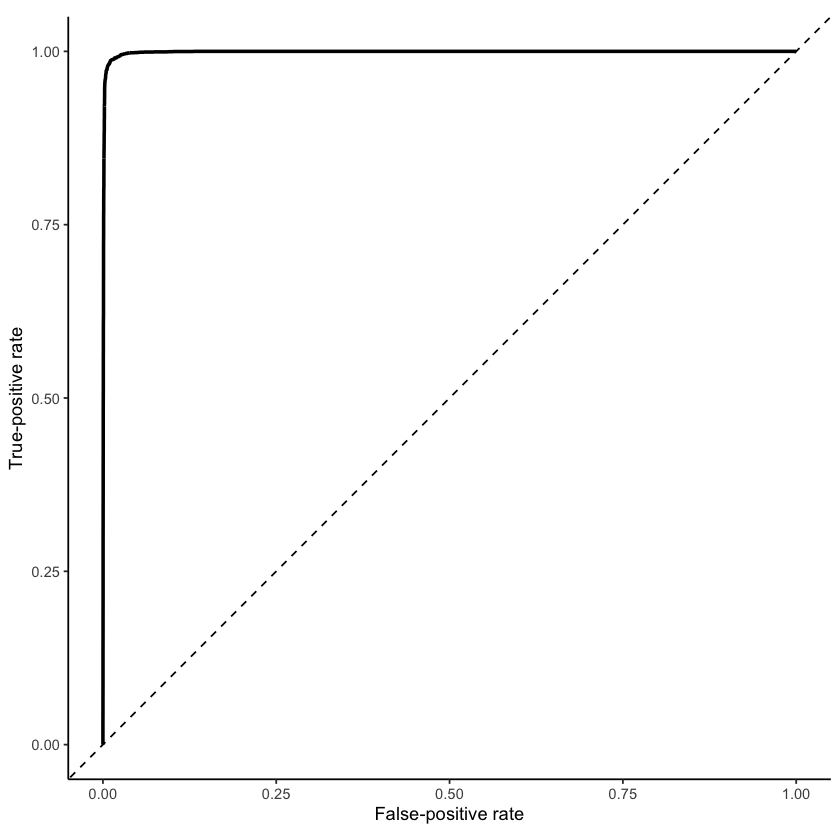

In [40]:
print(model.denovo)

ggplot(model.denovo$pred[model.denovo$pred$mtry==2 ,],
       aes(m = SNP, d = factor(obs, levels = c("SNP", "REF")))) +
    geom_roc(hjust = -0.4, vjust = 1.5, n.cuts = 0) + geom_abline(intercept = 0, lty=2) + coord_equal() + theme_classic() + xlab("False-positive rate") + ylab("True-positive rate")

confusionMatrix(data=model.denovo$pred[model.denovo$pred$mtry==2,]$pred, reference = model.denovo$pred[model.denovo$pred$mtry==2,]$obs, positive = "SNP")

Again, let's look at feature importance:

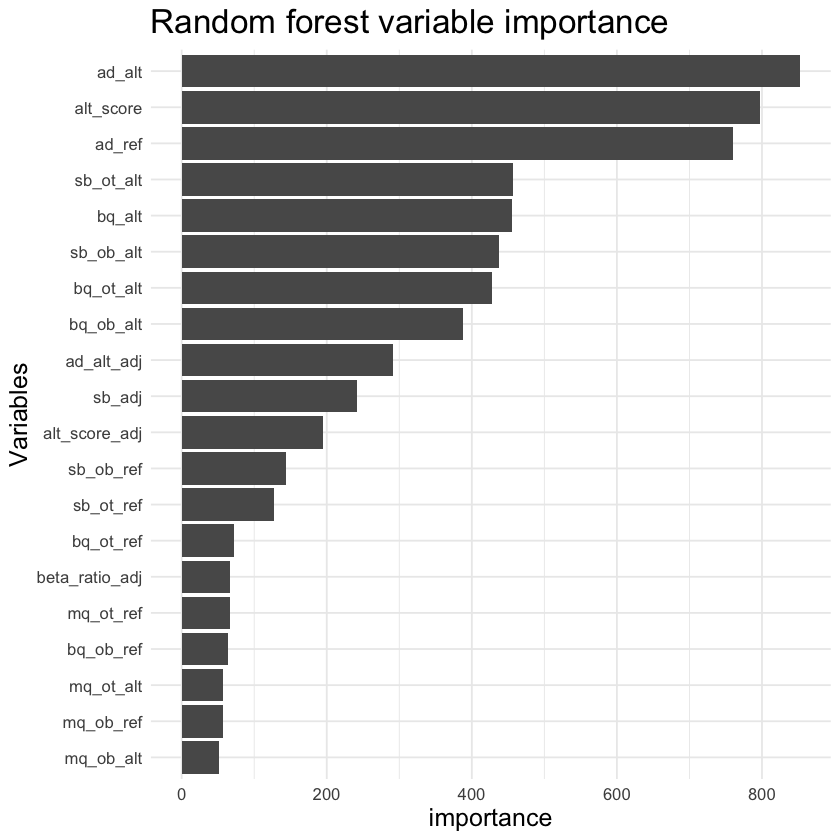

In [42]:
var_imp <- varImp(model.denovo, scale=FALSE)$importance
var_imp <- data.table(variables=row.names(var_imp), importance=var_imp$Overall)

## Create a plot of variable importance
ggplot(tail(var_imp[order(importance)], n=20), aes(x=reorder(variables, importance), y=importance)) +
        ## Plot the bar graph
        geom_bar(stat='identity') +
        ## Flip the graph to make a horizontal bar plot
        coord_flip() +
        ## Add x-axis label
        xlab('Variables') +
        ## Add a title
        labs(title='Random forest variable importance') +
        ## Some layout for the plot
        theme_minimal() +
        theme(axis.text = element_text(size = 10),
              axis.title = element_text(size = 15),
              plot.title = element_text(size = 20),
              )

## 3. Other SNPs

In [43]:
training_data.other <- training_data.long[
    !((alt=="C"|ref=="C")&substr(sequence_context, 4,4)=="G" | (alt=="G"|ref=="G")&substr(sequence_context, 2,2)=="C"),
    .(location=paste0(chr, ":", pos, "_", ref, ">" ,alt),
      ref,
      alt,
      is.snp,
      mapq,
      num_mapq0,
      p1 = substr(sequence_context, 1, 1),
      p2 = substr(sequence_context, 2, 2),
      p4 = substr(sequence_context, 4, 4),
      p5 = substr(sequence_context, 5, 5),
      region_entropy,
      ad_ref=ad_ref/depth,
      ad_alt=ad_alt/depth,
      sb_ot_ref = sb_ot_ref/depth,
      sb_ob_ref = sb_ob_ref/depth,
      sb_ot_alt = sb_ot_alt/depth,
      sb_ob_alt = sb_ob_alt/depth,
      sb_alt = (sb_ot_alt+1)/(sb_ob_alt+1),
      sb_ref = (sb_ot_ref+1)/(sb_ob_ref+1),
      alt_score = log2(ad_alt*bq_alt+1)-log2(ad_ref*bq_ref+1),
      bq_ref,
      bq_alt,
      bq_ot_ref,
      bq_ob_ref,
      bq_ot_alt,
      bq_ob_alt,
      mq_ot_ref,
      mq_ob_ref,
      mq_ot_alt,
      mq_ob_alt,
      mq_ref,
      mq_alt,
      pos_in_read_ref,
      pos_in_read_alt,
      num_aligned_bases_ref,
      num_aligned_bases_alt,
      num_indels_ref,
      num_indels_alt
      )
  ]

# turn into a data frame and remove location names
setDF(training_data.other)
rownames(training_data.other) <- training_data.other[,"location"]
training_data.other <- training_data.other[, colnames(training_data.other)!="location"]

# one-hot encode all categorical variables
training_data.other.dm <- dummyVars(" is.snp ~ .", data = training_data.other)
training_data.other.dm <- data.frame(predict(training_data.other.dm, newdata = training_data.other))
training_data.other.dm <- cbind(training_data.other.dm, data.frame(is.snp=as.factor(fifelse(training_data.other$is.snp, "SNP","REF"))))

rm(training_data.other)

training_data.other.dm <- training_data.other.dm[, !grepl("N", colnames(training_data.other.dm), fixed=TRUE)]

In [45]:
fwrite(training_data.other.dm, paste0("Analysis/data/", params$test_chr, "_other_features.txt.gz"), sep="\t", quote=FALSE, row.names=TRUE, col.names=TRUE, showProgress=FALSE, compress="gzip", scipen=15)

In [46]:
# Create a smaller training dataset with a pos:neg ratio of 1:3, ie a little more balanced than the actual data
indices.snp <- (1:nrow(training_data.other.dm))[training_data.other.dm$is.snp=="SNP"]
indices.ref <- (1:nrow(training_data.other.dm))[training_data.other.dm$is.snp=="REF"]

indices.train <- c(indices.snp[sample.int(length(indices.snp), 4000)], indices.ref[sample.int(length(indices.ref), 16000)])
rm(indices.snp, indices.ref)

# train a random forest
cl <- makePSOCKcluster(params$threads)
registerDoParallel(cl)
tunegrid <- expand.grid(.mtry=c(2,4,7))
ctrl <- trainControl(## 10-fold CV
                    method = "cv",
                    summaryFunction=twoClassSummary,
                    classProbs=TRUE,
                    savePredictions = TRUE,
                    number = 10,
                    ## repeated x times
                    #repeats = 3,
                    allowParallel=TRUE                    )

model.other <- train(is.snp ~ ., data=training_data.other.dm[indices.train,], method="rf", trControl=ctrl, tuneGrid=tunegrid, ntree=1000)
stopCluster(cl)

Warning message in train.default(x, y, weights = w, ...):
“The metric "Accuracy" was not in the result set. ROC will be used instead.”


Random Forest 

20000 samples
   54 predictor
    2 classes: 'REF', 'SNP' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 18000, 18000, 18000, 18000, 18000, 18000, ... 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec   
  2     0.9992211  0.9971875  0.98100
  4     0.9993902  0.9970625  0.98350
  7     0.9992508  0.9971875  0.98425

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 4.


Warning message in verify_d(data$d):
“D not labeled 0/1, assuming REF = 0 and SNP = 1!”


Confusion Matrix and Statistics

          Reference
Prediction   REF   SNP
       REF 15955    76
       SNP    45  3924
                                         
               Accuracy : 0.994          
                 95% CI : (0.9928, 0.995)
    No Information Rate : 0.8            
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.981          
                                         
 Mcnemar's Test P-Value : 0.006386       
                                         
            Sensitivity : 0.9810         
            Specificity : 0.9972         
         Pos Pred Value : 0.9887         
         Neg Pred Value : 0.9953         
             Prevalence : 0.2000         
         Detection Rate : 0.1962         
   Detection Prevalence : 0.1984         
      Balanced Accuracy : 0.9891         
                                         
       'Positive' Class : SNP            
                                      

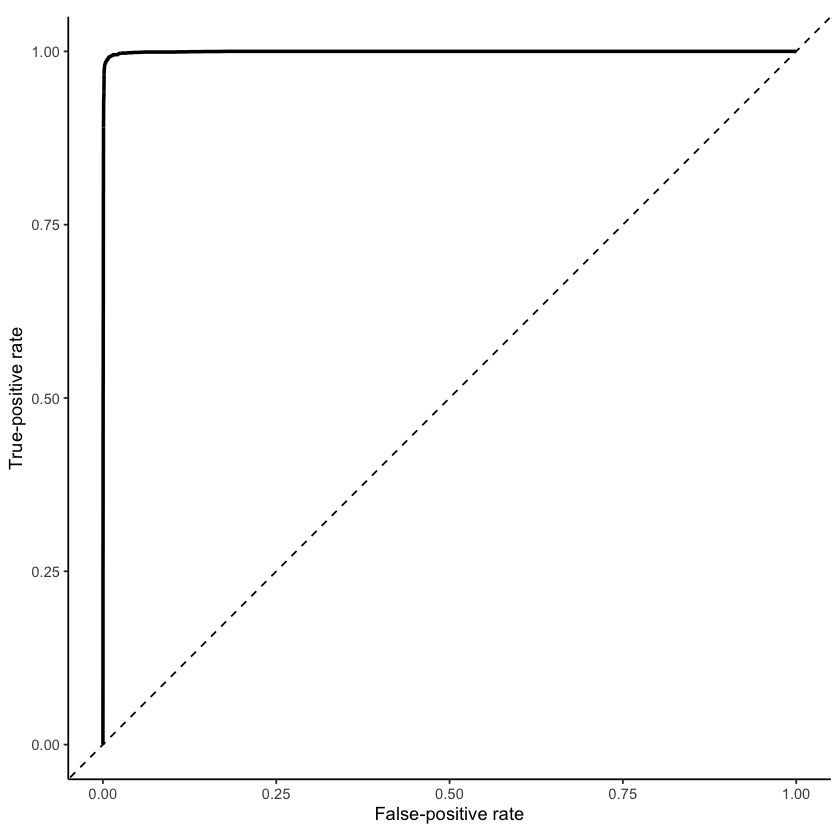

In [47]:
print(model.other)

ggplot(model.other$pred[model.other$pred$mtry==2 ,],
       aes(m = SNP, d = factor(obs, levels = c("SNP", "REF")))) +
    geom_roc(hjust = -0.4, vjust = 1.5, n.cuts = 0) + geom_abline(intercept = 0, lty=2) + coord_equal() + theme_classic() + xlab("False-positive rate") + ylab("True-positive rate")

confusionMatrix(data=model.other$pred[model.other$pred$mtry==2,]$pred, reference = model.other$pred[model.other$pred$mtry==2,]$obs, positive = "SNP")

And feature importance again:

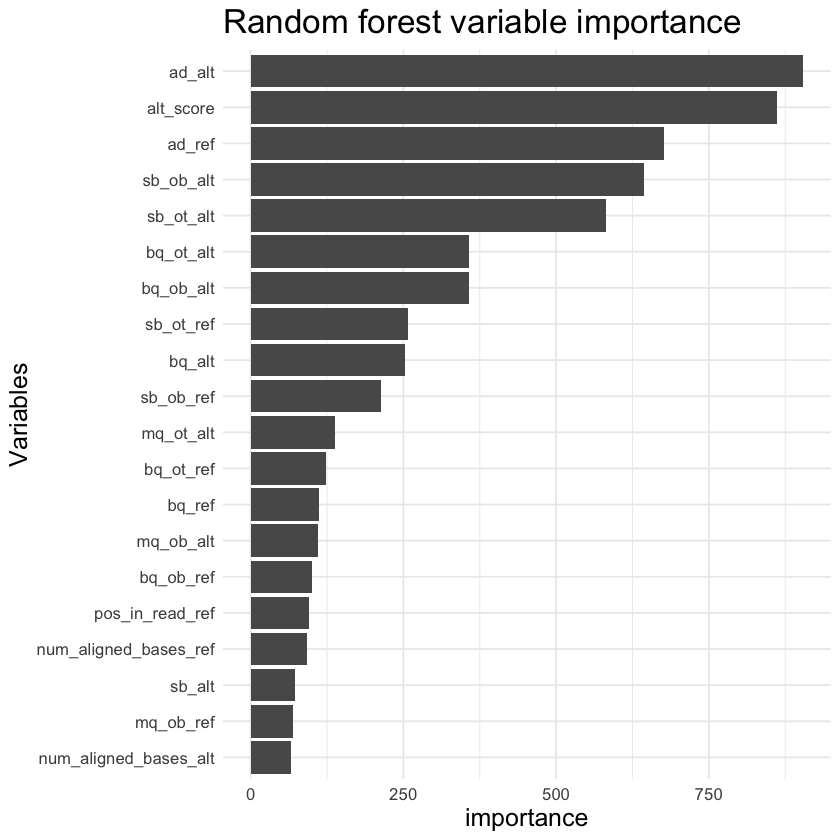

In [48]:
var_imp <- varImp(model.other, scale=FALSE)$importance
var_imp <- data.table(variables=row.names(var_imp), importance=var_imp$Overall)

## Create a plot of variable importance
ggplot(tail(var_imp[order(importance)], n=20), aes(x=reorder(variables, importance), y=importance)) +
        ## Plot the bar graph
        geom_bar(stat='identity') +
        ## Flip the graph to make a horizontal bar plot
        coord_flip() +
        ## Add x-axis label
        xlab('Variables') +
        ## Add a title
        labs(title='Random forest variable importance') +
        ## Some layout for the plot
        theme_minimal() +
        theme(axis.text = element_text(size = 10),
              axis.title = element_text(size = 15),
              plot.title = element_text(size = 20),
              )